# AI Defense Lab for Payment Security
## Closed-Loop Red Team vs Blue Team — Mastercard Innovation Challenge @ GFF 2026

**This notebook is self-contained**: it re-implements the full pipeline (data generation,
Blue-Team detector, Red-Team adversarial attack agent, closed-loop retraining, explainability,
evaluation, and visualization) in-line, so it runs top-to-bottom with **Run All** on a fresh
Kaggle CPU notebook with no external files.

> ⚠️ **All data below is 100% synthetic**, generated from statistical distributions chosen to
> resemble real payment-card behaviour. This notebook does not use, store, or claim to detect
> any real Mastercard cardholder or transaction data. Risk-score thresholds are demonstration
> thresholds for this challenge submission, **not** Mastercard production thresholds. Every
> number in this notebook is produced by the cells above it — nothing is hand-typed.

**Team pillars covered:** Identify (Section 3) → Generate (Sections 5, 9) → Defend (Sections 8, 11) → Closed Loop (Section 11) → Explain (Section 13) → Evaluate (Section 7, 12).


## 2. Problem Statement

Generative AI has lowered the cost and skill barrier for producing sophisticated, fast-evolving
payment fraud: automated card-testing bots, LLM-assisted social engineering for account takeover,
and adaptive evasion of static, rule-based fraud filters. Static defenses trained once on
historical fraud patterns degrade quickly against attackers who *actively* adapt.

**Goal of this project:** build one end-to-end system that (a) identifies a broad, realistic set
of GenAI-era payment-fraud attack vectors, (b) simulates them at scale with high fidelity, and
(c) trains a detector that keeps improving against them via a closed feedback loop — turning the
system's own simulated attacks into its training ground, the way the challenge brief specifies.


## 3. Threat Model — Identify

We ground the threat model in real payment-fraud TTPs (tactics, techniques, procedures) rather
than inventing arbitrary noise. Seven attack families are implemented and evaluated individually:

| # | Attack family | Real-world analogue |
|---|---|---|
| 1 | **Amount manipulation** | Shaving transaction amounts just under common authorization/step-up thresholds (e.g. contactless caps, 3-D Secure triggers) to avoid extra verification. |
| 2 | **Velocity attack** | Rapid bursts of transactions across merchants/devices in a short window — classic card-testing / bot-driven fraud. |
| 3 | **Merchant switching** | Spreading fraudulent spend across many merchant categories quickly to avoid single-merchant risk flags. |
| 4 | **Geographic anomaly evasion** | VPN/device-spoofing to make a stolen card's usage *look* geographically close to the cardholder's home, evading distance-based rules. |
| 5 | **Account takeover (ATO)** | Sudden combined shift in device, location, transaction amount, and velocity right after a credential-stuffing / phishing compromise. |
| 6 | **Low-and-slow fraud** | Many small transactions kept deliberately under common micro-transaction alert thresholds. |
| 7 | **Behavioral mimicry** | GenAI-style attacker that studies the account's own historical spending pattern and imitates it closely, sneaking in only one or two "tells". |

Each is implemented as a parameterized, *adaptive* attack persona (Section 9) rather than a single
static rule, because a real GenAI-powered adversary does not attack the same way twice.


## 4–5. Dataset & Data Generation

We generate a synthetic payment-transaction dataset with realistic statistical structure:
log-normal transaction amounts, diurnal (time-of-day) transaction cycles, Zipfian merchant
popularity, per-account spending profiles, and causally-computed velocity features (transaction
counts in the last 1h/24h, computed **only** from transactions strictly before the current one, to
avoid label leakage). Three *organic* fraud archetypes are baked into the base data (stolen-card
spikes, ATO bursts, card-testing) — separate from the Red-Team's adversarial attacks generated
later in Section 9, which specifically target the trained detector.

Reproducibility: every random draw comes from a single seeded `numpy.random.Generator`.


In [1]:
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

MERCHANT_CATEGORIES = [
    "grocery", "electronics", "travel", "restaurant", "fuel",
    "online_retail", "utilities", "entertainment", "healthcare",
    "jewelry", "gambling", "crypto_exchange", "money_transfer", "atm_withdrawal",
]
MERCHANT_RISK_PRIOR = {
    "grocery": 0.02, "electronics": 0.12, "travel": 0.10, "restaurant": 0.03,
    "fuel": 0.03, "online_retail": 0.10, "utilities": 0.01, "entertainment": 0.05,
    "healthcare": 0.02, "jewelry": 0.22, "gambling": 0.30, "crypto_exchange": 0.35,
    "money_transfer": 0.28, "atm_withdrawal": 0.15,
}
DEVICE_TYPES = ["mobile_app", "web_chrome", "web_safari", "pos_chip", "pos_contactless", "atm"]
PAYMENT_METHODS = ["chip", "contactless", "online_card_not_present", "magstripe", "wallet"]

@dataclass
class Account:
    account_id: str
    home_lat: float
    home_lon: float
    account_age_days: int
    avg_amount: float
    std_amount: float
    favourite_categories: list
    favourite_device: str
    monthly_txn_rate: float

def _sample_accounts(rng, n_accounts):
    accounts = []
    hubs = [(28.61, 77.20), (19.07, 72.87), (12.97, 77.59), (22.57, 88.36),
            (13.08, 80.27), (17.38, 78.48), (23.02, 72.57), (26.85, 80.94)]
    for i in range(n_accounts):
        hub = hubs[rng.integers(0, len(hubs))]
        home_lat = hub[0] + rng.normal(0, 0.35)
        home_lon = hub[1] + rng.normal(0, 0.35)
        age = int(rng.exponential(650)) + 30
        avg_amount = float(np.clip(rng.lognormal(mean=6.2, sigma=0.9), 50, 20000))
        std_amount = avg_amount * rng.uniform(0.2, 0.6)
        fav_cats = list(rng.choice(MERCHANT_CATEGORIES, size=rng.integers(2, 5), replace=False))
        fav_device = DEVICE_TYPES[rng.integers(0, len(DEVICE_TYPES))]
        monthly_rate = float(np.clip(rng.gamma(shape=2.0, scale=1.1), 0.05, 8.0))
        accounts.append(Account(f"ACC{i:06d}", home_lat, home_lon, age, avg_amount, std_amount,
                                 fav_cats, fav_device, monthly_rate))
    return accounts

def _haversine(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1); dl = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*r*np.arcsin(np.sqrt(a))

print("Helper functions ready.")

Helper functions ready.


In [2]:
def generate_transactions(n_accounts=700, fraud_rate=0.02, seed=42,
                           start=datetime(2026,1,1), days=60):
    rng = np.random.default_rng(seed)
    accounts = _sample_accounts(rng, n_accounts)
    rows = []
    txn_counter = 0
    for acc in accounts:
        expected_txns = max(1, int(acc.monthly_txn_rate * days * rng.uniform(0.7, 1.3)))
        day_offsets = rng.integers(0, days, size=expected_txns)
        hour_modes = rng.choice([10, 13, 19], size=expected_txns, p=[0.35, 0.30, 0.35])
        hours = np.clip(rng.normal(hour_modes, 2.2), 0, 23.9)
        failed_count = 0
        order = np.argsort(day_offsets + hours/24.0)
        for k in order:
            txn_counter += 1
            ts = start + timedelta(days=float(day_offsets[k]), hours=float(hours[k]))
            is_fraud = rng.random() < fraud_rate
            if is_fraud:
                archetype = rng.choice(["stolen_card_spike", "ato_burst", "card_testing"])
                if archetype == "stolen_card_spike":
                    amount = float(np.clip(rng.lognormal(np.log(acc.avg_amount*4), 0.6), 100, 150000))
                    category = rng.choice(["electronics","jewelry","crypto_exchange","gambling","online_retail"])
                    device = rng.choice([d for d in DEVICE_TYPES if d != acc.favourite_device])
                    dist_km = float(np.clip(rng.exponential(600), 5, 15000))
                elif archetype == "ato_burst":
                    amount = float(np.clip(rng.lognormal(np.log(max(acc.avg_amount,50)*2.2), 0.5), 50, 80000))
                    category = rng.choice(["money_transfer","crypto_exchange","electronics"])
                    device = rng.choice(DEVICE_TYPES)
                    dist_km = float(np.clip(rng.exponential(300), 1, 9000))
                else:
                    amount = float(np.clip(rng.normal(2.5, 1.2), 0.5, 15))
                    category = rng.choice(["online_retail","utilities","entertainment"])
                    device = "web_chrome"
                    dist_km = float(np.clip(rng.exponential(150), 0, 5000))
                failed_count = int(np.clip(failed_count + rng.integers(0,3), 0, 20))
            else:
                category = rng.choice(acc.favourite_categories) if rng.random() < 0.75 else rng.choice(MERCHANT_CATEGORIES)
                amount = float(np.clip(rng.lognormal(np.log(max(acc.avg_amount,10)), 0.55), 1, 50000))
                device = acc.favourite_device if rng.random() < 0.85 else rng.choice(DEVICE_TYPES)
                dist_km = float(np.clip(rng.exponential(8) if rng.random()<0.9 else rng.exponential(200), 0, 12000))
                failed_count = int(np.clip(failed_count + (1 if rng.random()<0.03 else -1), 0, 20))
            lat = acc.home_lat + rng.normal(0,0.05) if dist_km < 20 else acc.home_lat + rng.normal(0,3)
            lon = acc.home_lon + rng.normal(0,0.05) if dist_km < 20 else acc.home_lon + rng.normal(0,3)
            actual_dist = _haversine(acc.home_lat, acc.home_lon, lat, lon)
            payment_method = rng.choice(PAYMENT_METHODS, p=[0.30,0.28,0.22,0.08,0.12])
            merchant_risk = float(np.clip(MERCHANT_RISK_PRIOR[category] + rng.normal(0,0.03), 0.005, 0.9))
            rows.append({"transaction_id": f"TXN{txn_counter:08d}", "account_id": acc.account_id,
                "timestamp": ts, "amount": round(amount,2), "merchant_category": category,
                "merchant_risk_score": round(merchant_risk,4), "device_type": device,
                "payment_method": payment_method, "geo_distance_km": round(float(actual_dist),2),
                "account_age_days": acc.account_age_days, "failed_txn_count_recent": failed_count,
                "fraud_label": int(is_fraud)})
    df = pd.DataFrame(rows).sort_values(["account_id","timestamp"]).reset_index(drop=True)

    # causal velocity features (no leakage: only look backwards in time)
    df["prev_txn_time"] = df.groupby("account_id")["timestamp"].shift(1)
    df["seconds_since_prev_txn"] = (df["timestamp"] - df["prev_txn_time"]).dt.total_seconds()
    df["seconds_since_prev_txn"] = df["seconds_since_prev_txn"].fillna(df["seconds_since_prev_txn"].median())
    df["txn_count_last_1h"] = 0; df["txn_count_last_24h"] = 0; df["amount_avg_last_5"] = np.nan
    for acc_id, g in df.groupby("account_id", sort=False):
        idx = g.index
        times = g["timestamp"].values.astype("datetime64[s]").astype(np.int64)
        amounts = g["amount"].values
        n = len(g); c1h = np.zeros(n,dtype=int); c24h = np.zeros(n,dtype=int); avg5 = np.full(n, np.nan)
        j1=j24=0
        for i in range(n):
            while times[i]-times[j1] > 3600: j1 += 1
            while times[i]-times[j24] > 86400: j24 += 1
            c1h[i]=i-j1; c24h[i]=i-j24
            avg5[i] = amounts[max(0,i-5):i].mean() if i>0 else amounts[i]
        df.loc[idx,"txn_count_last_1h"]=c1h; df.loc[idx,"txn_count_last_24h"]=c24h; df.loc[idx,"amount_avg_last_5"]=avg5
    df["amount_avg_last_5"] = df["amount_avg_last_5"].fillna(df["amount"])
    df["amount_deviation_ratio"] = (df["amount"]/df["amount_avg_last_5"].replace(0,np.nan)).fillna(1.0)
    df["is_new_device_hint"] = (rng.random(len(df)) < 0.08).astype(int)
    df["hour_of_day"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df.drop(columns=["prev_txn_time"])

df = generate_transactions(n_accounts=700, fraud_rate=0.02, seed=42, days=60)
print("Shape:", df.shape)
print(df["fraud_label"].value_counts(normalize=True))
df.head()

Shape: (92803, 21)
fraud_label
0    0.980572
1    0.019428
Name: proportion, dtype: float64


,transaction_id,account_id,timestamp,amount,merchant_category,merchant_risk_score,device_type,payment_method,geo_distance_km,account_age_days,...,fraud_label,seconds_since_prev_txn,txn_count_last_1h,txn_count_last_24h,amount_avg_last_5,amount_deviation_ratio,is_new_device_hint,hour_of_day,day_of_week,is_weekend
0,TXN00000001,ACC000000,2026-01-01 09:24:40.552496,141.38,money_transfer,0.2594,web_safari,magstripe,565.09,211,...,0,15222.038350,0,0,141.380000,1.000000,0,9,3,0
1,TXN00000002,ACC000000,2026-01-02 18:57:52.663551,50.16,money_transfer,0.3118,web_safari,chip,466.11,211,...,0,120792.111055,0,0,141.380000,0.354789,0,18,4,0
2,TXN00000003,ACC000000,2026-01-02 19:48:06.964021,41.94,crypto_exchange,0.3279,web_safari,wallet,4.02,211,...,0,3014.300470,1,1,95.770000,0.437924,0,19,4,0
3,TXN00000004,ACC000000,2026-01-02 21:32:25.478252,76.52,healthcare,0.0412,web_safari,contactless,8.39,211,...,0,6258.514231,0,2,77.826667,0.983211,1,21,4,0
4,TXN00000005,ACC000000,2026-01-03 05:53:56.311905,83.66,money_transfer,0.2946,web_safari,online_card_not_present,4.31,211,...,0,30090.833653,0,3,77.500000,1.079484,0,5,5,1


## 6. Exploratory Data Analysis

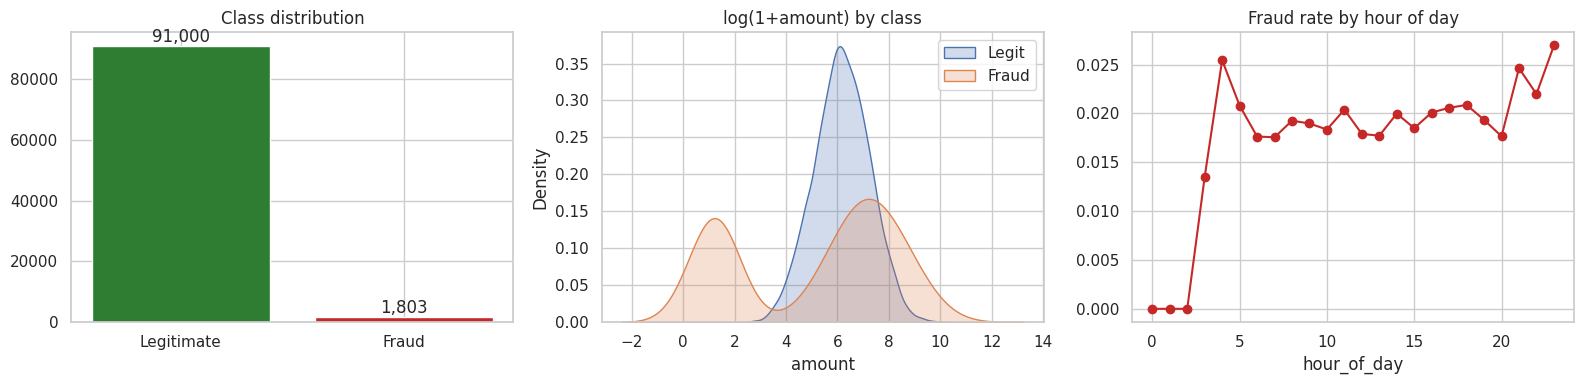

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
counts = df["fraud_label"].value_counts().rename({0:"Legitimate",1:"Fraud"})
axes[0].bar(counts.index, counts.values, color=["#2e7d32","#c62828"])
axes[0].set_title("Class distribution")
for i,v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

sample = df.sample(min(20000,len(df)), random_state=1)
sns.kdeplot(np.log1p(sample.loc[sample.fraud_label==0,"amount"]), label="Legit", fill=True, ax=axes[1])
sns.kdeplot(np.log1p(sample.loc[sample.fraud_label==1,"amount"]), label="Fraud", fill=True, ax=axes[1])
axes[1].set_title("log(1+amount) by class"); axes[1].legend()

df.groupby("hour_of_day")["fraud_label"].mean().plot(ax=axes[2], marker="o", color="#c62828")
axes[2].set_title("Fraud rate by hour of day")
plt.tight_layout(); plt.show()

## 7. Feature Engineering & Leakage-Safe Split

**Leakage-avoidance rules applied:**
1. Chronological split (train = earliest 60%, val = next 20%, test = last 20%) — never a random
   split — so validation/test always simulate the future relative to training.
2. Scaler/encoder are `fit` only on the training partition.
3. Row identifiers (`account_id`, `transaction_id`, `timestamp`) are excluded from model features.
4. All velocity features were computed causally in Section 5 (only look backwards in time).


In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

CATEGORICAL_COLS = ["merchant_category", "device_type", "payment_method"]
NUMERIC_COLS = ["amount","merchant_risk_score","geo_distance_km","account_age_days",
    "failed_txn_count_recent","seconds_since_prev_txn","txn_count_last_1h","txn_count_last_24h",
    "amount_avg_last_5","amount_deviation_ratio","is_new_device_hint","hour_of_day","day_of_week","is_weekend"]
LABEL_COL = "fraud_label"

def engineer_features(d):
    d = d.copy()
    d["velocity_score"] = (d["txn_count_last_1h"]*3 + d["txn_count_last_24h"]).astype(float)
    d["amount_log"] = np.log1p(d["amount"])
    d["is_high_risk_merchant"] = (d["merchant_risk_score"] > 0.20).astype(int)
    d["is_far_from_home"] = (d["geo_distance_km"] > 100).astype(int)
    d["rapid_repeat_txn"] = (d["seconds_since_prev_txn"] < 60).astype(int)
    return d

def chronological_split(d, train_frac=0.6, val_frac=0.2):
    d = d.sort_values("timestamp").reset_index(drop=True)
    n = len(d); i_tr = int(n*train_frac); i_val = int(n*(train_frac+val_frac))
    return d.iloc[:i_tr].copy(), d.iloc[i_tr:i_val].copy(), d.iloc[i_val:].copy()

def fit_transform_splits(d):
    d = engineer_features(d)
    numeric_cols = NUMERIC_COLS + ["velocity_score","amount_log","is_high_risk_merchant","is_far_from_home","rapid_repeat_txn"]
    train_df, val_df, test_df = chronological_split(d)
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False); encoder.fit(train_df[CATEGORICAL_COLS])
    scaler = StandardScaler(); scaler.fit(train_df[numeric_cols])
    def build(part):
        num = scaler.transform(part[numeric_cols]); cat = encoder.transform(part[CATEGORICAL_COLS])
        cat_names = encoder.get_feature_names_out(CATEGORICAL_COLS)
        X = pd.DataFrame(np.hstack([num,cat]), columns=numeric_cols+list(cat_names), index=part.index).reset_index(drop=True)
        y = part[LABEL_COL].reset_index(drop=True)
        return X, y
    X_train,y_train = build(train_df); X_val,y_val = build(val_df); X_test,y_test = build(test_df)
    return X_train,y_train,X_val,y_val,X_test,y_test,scaler,encoder,list(X_train.columns)

def transform_new(rows_df, scaler, encoder, feature_names):
    d = engineer_features(rows_df)
    numeric_cols = NUMERIC_COLS + ["velocity_score","amount_log","is_high_risk_merchant","is_far_from_home","rapid_repeat_txn"]
    num = scaler.transform(d[numeric_cols]); cat = encoder.transform(d[CATEGORICAL_COLS])
    cat_names = encoder.get_feature_names_out(CATEGORICAL_COLS)
    X = pd.DataFrame(np.hstack([num,cat]), columns=numeric_cols+list(cat_names), index=d.index)
    return X[feature_names]

X_train,y_train,X_val,y_val,X_test,y_test,scaler,encoder,feature_names = fit_transform_splits(df)
print("train/val/test:", X_train.shape, X_val.shape, X_test.shape)
print("fraud rate train/val/test:", y_train.mean(), y_val.mean(), y_test.mean())

train/val/test: (55681, 44) (18561, 44) (18561, 44)
fraud rate train/val/test: 0.019216608897110327 0.019395506707612736 0.02009590000538764


## 8. Baseline Blue-Team Model

Trains Random Forest, XGBoost (falls back to `HistGradientBoostingClassifier` if XGBoost is
unavailable), and an Isolation Forest anomaly detector. **The final model is selected by
validation PR-AUC**, not accuracy — with ~2% fraud, a trivial "always legitimate" classifier
already scores ~98% accuracy, so PR-AUC (and recall at a usable precision) is what actually
distinguishes a useful detector on this imbalanced problem.


In [5]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

RISK_BANDS = [(0,30,"Low Risk"),(31,60,"Medium Risk"),(61,80,"High Risk"),(81,100,"Critical Risk")]
def risk_score(prob): return np.clip(np.round(np.asarray(prob)*100,1), 0, 100)
def risk_band(score):
    for lo,hi,name in RISK_BANDS:
        if lo <= score <= hi: return name
    return "Critical Risk"

class BlueTeamDetector:
    def __init__(self, feature_names, seed=42):
        self.feature_names = feature_names; self.seed = seed; self.models = {}
        self.best_model_name = None; self.iso_forest = None
    def fit(self, X_tr, y_tr, X_v, y_v):
        n_pos, n_neg = y_tr.sum(), len(y_tr)-y_tr.sum()
        spw = n_neg / max(n_pos,1)
        rf = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=3,
            class_weight="balanced_subsample", n_jobs=-1, random_state=self.seed)
        rf.fit(X_tr, y_tr); self.models["random_forest"] = rf
        if HAS_XGB:
            gb = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1, subsample=0.85,
                colsample_bytree=0.85, scale_pos_weight=spw, eval_metric="aucpr", random_state=self.seed, n_jobs=-1)
            gb.fit(X_tr, y_tr); self.models["xgboost"] = gb
        else:
            gb = HistGradientBoostingClassifier(max_depth=8, learning_rate=0.08, max_iter=200,
                class_weight="balanced", random_state=self.seed)
            gb.fit(X_tr, y_tr); self.models["hist_gradient_boosting"] = gb
        iso = IsolationForest(n_estimators=120, contamination=float(np.clip(y_tr.mean(),0.005,0.05)),
            random_state=self.seed, n_jobs=-1)
        iso.fit(X_tr[y_tr==0]); self.iso_forest = iso
        val_scores = {name: average_precision_score(y_v, m.predict_proba(X_v)[:,1]) for name,m in self.models.items()}
        self.best_model_name = max(val_scores, key=val_scores.get)
        return val_scores
    @property
    def best_model(self): return self.models[self.best_model_name]
    def predict_proba(self, X): return self.best_model.predict_proba(X)[:,1]
    def predict(self, X, threshold=0.5): return (self.predict_proba(X) >= threshold).astype(int)
    def evaluate(self, X, y, threshold=0.5):
        proba = self.predict_proba(X); pred = (proba>=threshold).astype(int)
        return {"model_used": self.best_model_name, "accuracy": accuracy_score(y,pred),
            "precision": precision_score(y,pred,zero_division=0), "recall": recall_score(y,pred,zero_division=0),
            "f1_score": f1_score(y,pred,zero_division=0),
            "roc_auc": roc_auc_score(y,proba) if y.nunique()>1 else float("nan"),
            "pr_auc": average_precision_score(y,proba) if y.nunique()>1 else float("nan"),
            "confusion_matrix": confusion_matrix(y,pred).tolist(), "n_samples": int(len(y)), "n_fraud": int(y.sum())}
    def feature_importance(self):
        m = self.best_model
        return pd.Series(m.feature_importances_, index=self.feature_names).sort_values(ascending=False)

detector = BlueTeamDetector(feature_names)
val_scores = detector.fit(X_train, y_train, X_val, y_val)
print("Validation PR-AUC per model:", val_scores)
print("Selected model:", detector.best_model_name)
test_metrics = detector.evaluate(X_test, y_test)
for k,v in test_metrics.items():
    if k != "confusion_matrix": print(f"  {k}: {v}")
print("Confusion matrix:", test_metrics["confusion_matrix"])

Validation PR-AUC per model: {'random_forest': 0.8859723650298128, 'xgboost': 0.9115634344965559}
Selected model: xgboost
  model_used: xgboost
  accuracy: 0.9825440439631485
  precision: 0.5383411580594679
  recall: 0.9222520107238605
  f1_score: 0.6798418972332015
  roc_auc: 0.9952904752330589
  pr_auc: 0.9136866953078998
  n_samples: 18561
  n_fraud: 373
Confusion matrix: [[17893, 295], [29, 344]]


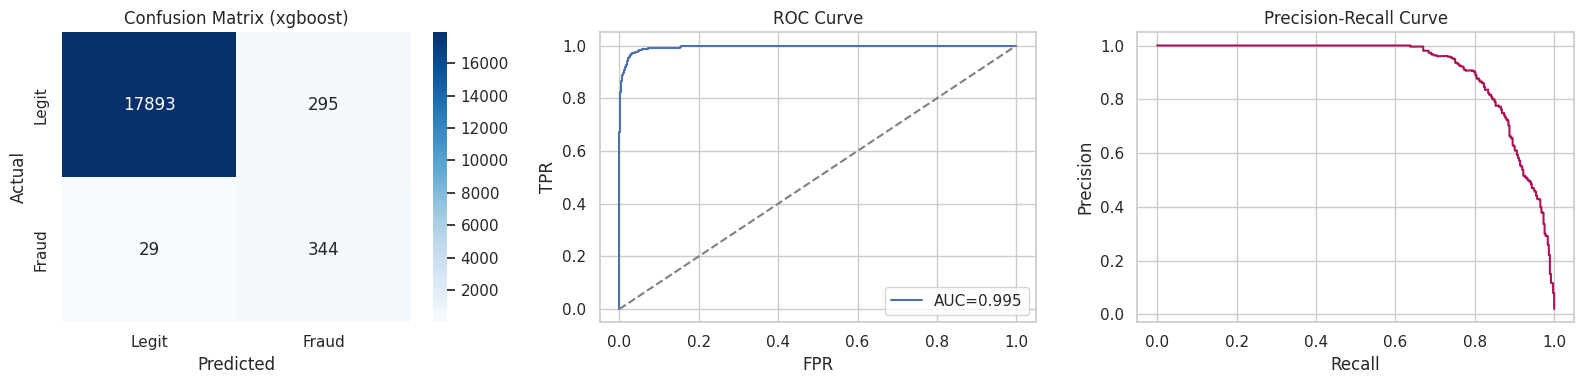

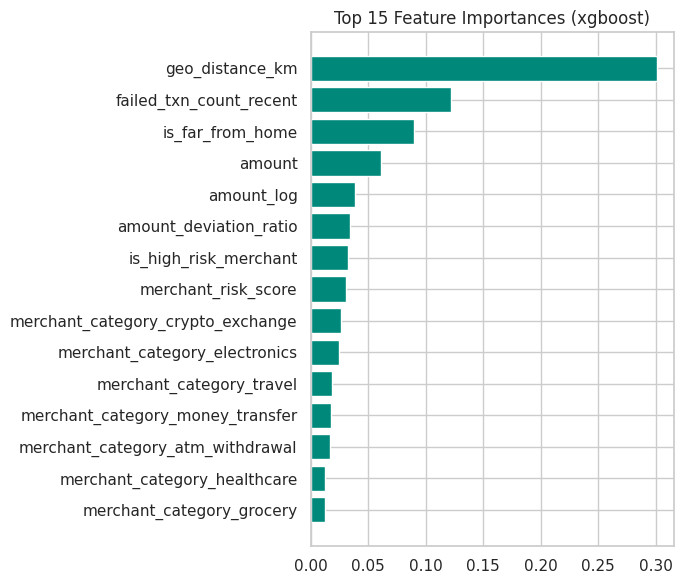

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
cm = np.array(test_metrics["confusion_matrix"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=["Legit","Fraud"], yticklabels=["Legit","Fraud"])
axes[0].set_title(f"Confusion Matrix ({detector.best_model_name})"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

proba_test = detector.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, label=f"AUC={test_metrics['roc_auc']:.3f}"); axes[1].plot([0,1],[0,1],"--",color="grey")
axes[1].set_title("ROC Curve"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[2].plot(rec, prec, color="#ad1457"); axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
plt.tight_layout(); plt.show()

imp = detector.feature_importance().head(15).sort_values()
plt.figure(figsize=(7,6)); plt.barh(imp.index, imp.values, color="#00897b")
plt.title(f"Top 15 Feature Importances ({detector.best_model_name})"); plt.tight_layout(); plt.show()

## 9. Red-Team Attack Simulator — Generate

**On "GenAI-powered":** rather than calling a paid external LLM API (avoided per the challenge's
own reproducibility guidance), we implement an **adaptive attack-persona agent** — a parametrized
generator whose parameters (`intensity`, `stealth_bias`) are evolved round-over-round using the
Blue Team's own feedback (its miss-rate per attack family), via a simple hill-climbing update. This
reproduces the *behaviour* of a generative adversarial fraud actor — attacks that adapt to what a
defense is currently missing — while staying fully local and reproducible. This is documented
honestly here as a heuristic adaptive agent, not a claim of using a hosted LLM.


In [7]:
ATTACK_TYPES = ["amount_manipulation","velocity_attack","merchant_switching","geo_evasion",
                "account_takeover","low_and_slow","behavioral_mimicry"]
COMMON_AUTH_THRESHOLDS = [50,100,200,500,1000,2000,5000]

@dataclass
class AttackPersona:
    attack_type: str; intensity: float = 0.5; stealth_bias: float = 0.5
    rounds_played: int = 0; history: list = field(default_factory=list)

class RedTeamAgent:
    def __init__(self, rng_seed=7):
        self.rng = np.random.default_rng(rng_seed)
        self.personas = {a: AttackPersona(a) for a in ATTACK_TYPES}

    def _amount_manipulation(self, t, p):
        t = t.copy(); threshold = self.rng.choice(COMMON_AUTH_THRESHOLDS)
        shave = self.rng.uniform(0.01,0.15) * (1-p.stealth_bias*0.5)
        t["amount"] = round(max(1.0, threshold*(1-shave)), 2)
        t["amount_deviation_ratio"] = t["amount"] / max(t.get("amount_avg_last_5", t["amount"]), 1)
        return t
    def _velocity_attack(self, t, p):
        t = t.copy(); burst = int(3 + p.intensity*15)
        t["txn_count_last_1h"] = int(t.get("txn_count_last_1h",0) + burst)
        t["txn_count_last_24h"] = int(t.get("txn_count_last_24h",0) + burst*self.rng.integers(1,4))
        t["seconds_since_prev_txn"] = max(1.0, 60*(1-p.intensity)); return t
    def _merchant_switching(self, t, p):
        t = t.copy(); cats=["electronics","crypto_exchange","jewelry","gambling","money_transfer","online_retail","travel"]
        t["merchant_category"] = self.rng.choice(cats)
        t["merchant_risk_score"] = float(np.clip(self.rng.uniform(0.15,0.4)*(1-p.stealth_bias*0.4), 0.02, 0.9))
        return t
    def _geo_evasion(self, t, p):
        t = t.copy(); t["geo_distance_km"] = round(float(self.rng.uniform(0.5,15)*(1-p.intensity*0.3)),2); return t
    def _account_takeover(self, t, p):
        t = t.copy(); t["device_type"] = self.rng.choice(["web_chrome","mobile_app","web_safari"])
        t["geo_distance_km"] = round(float(self.rng.uniform(200,3000)*(1-p.stealth_bias*0.3)),2)
        t["amount"] = round(max(1.0, t["amount"]*self.rng.uniform(2.0,6.0)*(1-p.stealth_bias*0.3)),2)
        t["txn_count_last_1h"] = int(t.get("txn_count_last_1h",0) + int(2+p.intensity*6))
        t["failed_txn_count_recent"] = int(t.get("failed_txn_count_recent",0) + self.rng.integers(1,4))
        return t
    def _low_and_slow(self, t, p):
        t = t.copy(); cap = 15*(1+p.stealth_bias); t["amount"] = round(float(self.rng.uniform(0.5,cap)),2)
        t["txn_count_last_24h"] = int(t.get("txn_count_last_24h",0)+int(1+p.intensity*3))
        t["seconds_since_prev_txn"] = float(self.rng.uniform(1800,21600)); return t
    def _behavioral_mimicry(self, t, p, profile):
        t = t.copy()
        if profile:
            t["amount"] = round(float(np.clip(self.rng.normal(profile["avg_amount"], profile["std_amount"]),1,1e6)),2)
            t["merchant_category"] = profile["favourite_category"]; t["device_type"] = profile["favourite_device"]
        t["failed_txn_count_recent"] = int(t.get("failed_txn_count_recent",0) + (1 if self.rng.random()<0.4 else 0))
        return t

    def craft_attack(self, txn, attack_type, account_profile=None):
        persona = self.personas[attack_type]
        fn = {"amount_manipulation":self._amount_manipulation,"velocity_attack":self._velocity_attack,
              "merchant_switching":self._merchant_switching,"geo_evasion":self._geo_evasion,
              "account_takeover":self._account_takeover,"low_and_slow":self._low_and_slow}.get(attack_type)
        attacked = self._behavioral_mimicry(txn, persona, account_profile) if attack_type=="behavioral_mimicry" else fn(txn, persona)
        attacked["attack_type"]=attack_type; attacked["attack_intensity"]=round(persona.intensity,3); attacked["fraud_label"]=1
        return attacked

    def generate_attack_batch(self, base_df, n_per_type=150, account_profiles=None):
        rows = []
        base_sample = base_df.sample(n=min(len(base_df), n_per_type*len(ATTACK_TYPES)),
            replace=len(base_df) < n_per_type*len(ATTACK_TYPES), random_state=int(self.rng.integers(0,1_000_000)))
        base_records = base_sample.to_dict("records"); idx=0
        for attack_type in ATTACK_TYPES:
            for _ in range(n_per_type):
                base_txn = base_records[idx % len(base_records)]; idx += 1
                profile = account_profiles.get(base_txn.get("account_id")) if account_profiles else None
                attacked = self.craft_attack(dict(base_txn), attack_type, profile)
                attacked["original_amount"] = base_txn["amount"]
                rows.append(attacked)
        return pd.DataFrame(rows)

    def adapt(self, detection_rate_by_type):
        for attack_type, det_rate in detection_rate_by_type.items():
            p = self.personas[attack_type]; p.history.append(det_rate); p.rounds_played += 1
            step = 0.12
            if det_rate > 0.6:
                p.stealth_bias = float(np.clip(p.stealth_bias+step,0.05,0.95)); p.intensity = float(np.clip(p.intensity-step*0.5,0.05,0.95))
            elif det_rate < 0.25:
                p.intensity = float(np.clip(p.intensity+step,0.05,0.95)); p.stealth_bias = float(np.clip(p.stealth_bias-step*0.3,0.05,0.95))
            else:
                p.intensity = float(np.clip(p.intensity+self.rng.normal(0,0.05),0.05,0.95))
                p.stealth_bias = float(np.clip(p.stealth_bias+self.rng.normal(0,0.05),0.05,0.95))

    def persona_state(self):
        return pd.DataFrame([{"attack_type":p.attack_type,"intensity":p.intensity,"stealth_bias":p.stealth_bias,
            "rounds_played":p.rounds_played,"last_detection_rate":(p.history[-1] if p.history else None)} for p in self.personas.values()])

legit = df[df["fraud_label"]==0]
agent = RedTeamAgent(rng_seed=7)
attack_batch_demo = agent.generate_attack_batch(legit, n_per_type=100)
print(attack_batch_demo.shape)
attack_batch_demo["attack_type"].value_counts()

(700, 24)


attack_type
amount_manipulation    100
velocity_attack        100
merchant_switching     100
geo_evasion            100
account_takeover       100
low_and_slow           100
behavioral_mimicry     100
Name: count, dtype: int64

## 10. Attack Evaluation — how well does the BASELINE detector catch these attacks?

In [8]:
def evaluate_attack_batch(det, attack_df, X_attack, threshold=0.5):
    proba = det.predict_proba(X_attack); pred = (proba>=threshold).astype(int)
    out = attack_df[["attack_type"]].copy().reset_index(drop=True)
    out["risk_score"] = np.clip(np.round(proba*100,1),0,100); out["detected"] = pred; out["missed"] = 1-pred
    summary = out.groupby("attack_type").agg(number_generated=("attack_type","count"), number_detected=("detected","sum"),
        avg_risk_score=("risk_score","mean")).reset_index()
    summary["number_missed"] = summary["number_generated"]-summary["number_detected"]
    summary["detection_rate"] = (summary["number_detected"]/summary["number_generated"]).round(4)
    summary["false_negative_rate"] = (summary["number_missed"]/summary["number_generated"]).round(4)
    summary["avg_risk_score"] = summary["avg_risk_score"].round(2)
    return summary.sort_values("detection_rate"), out

def build_account_profiles(d):
    profiles = {}
    for acc_id, g in d[d.fraud_label==0].groupby("account_id"):
        profiles[acc_id] = {"avg_amount": float(g["amount"].mean()), "std_amount": float(max(g["amount"].std(),1.0)),
            "favourite_category": g["merchant_category"].mode().iloc[0], "favourite_device": g["device_type"].mode().iloc[0]}
    return profiles

account_profiles = build_account_profiles(df)
attack_batch = agent.generate_attack_batch(legit, n_per_type=150, account_profiles=account_profiles)
X_attack = transform_new(attack_batch, scaler, encoder, feature_names)
summary_before, per_row_before = evaluate_attack_batch(detector, attack_batch, X_attack)
print("=== BEFORE closed-loop training: per-attack-type detection ===")
print(summary_before.to_string(index=False))
print("\nOverall detection rate:", round(per_row_before["detected"].mean(),4),
      "| Overall avg risk score:", round(per_row_before["risk_score"].mean(),2))

=== BEFORE closed-loop training: per-attack-type detection ===
        attack_type  number_generated  number_detected  avg_risk_score  number_missed  detection_rate  false_negative_rate
        geo_evasion               150                0            0.28            150          0.0000               1.0000
    velocity_attack               150                3            2.41            147          0.0200               0.9800
 behavioral_mimicry               150                5            4.85            145          0.0333               0.9667
amount_manipulation               150                5            4.79            145          0.0333               0.9667
 merchant_switching               150                5            5.31            145          0.0333               0.9667
       low_and_slow               150                7            6.99            143          0.0467               0.9533
   account_takeover               150               83           55.09      

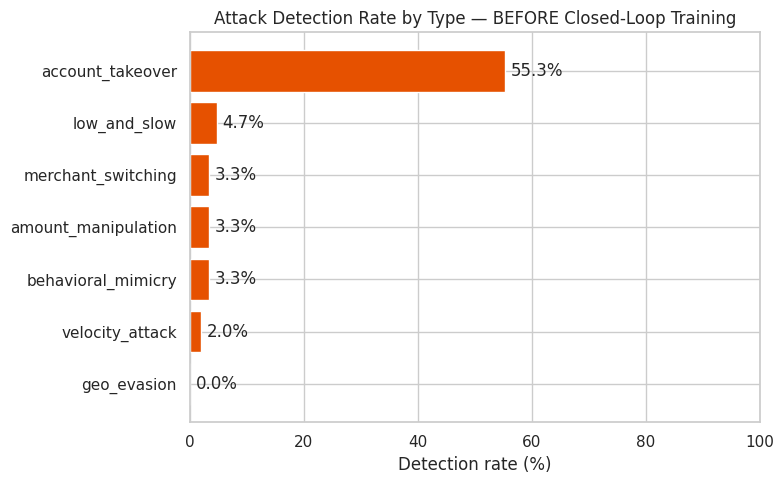

In [9]:
r1 = summary_before.sort_values("detection_rate")
plt.figure(figsize=(8,5))
plt.barh(r1["attack_type"], r1["detection_rate"]*100, color="#e65100")
plt.xlabel("Detection rate (%)"); plt.xlim(0,100)
plt.title("Attack Detection Rate by Type — BEFORE Closed-Loop Training")
for i,v in enumerate(r1["detection_rate"]*100): plt.text(v+1, i, f"{v:.1f}%", va="center")
plt.tight_layout(); plt.show()

## 11. Closed-Loop Adversarial Training — Defend + Improve

```
NORMAL TRAINING DATA -> BLUE TEAM DETECTOR -> RED TEAM ATTACK GENERATION
-> ATTACKED TRANSACTIONS -> BLUE TEAM DETECTION -> MISSED ATTACKS
-> ADVERSARIAL TRAINING DATA -> RETRAIN BLUE TEAM -> RE-EVALUATE -> IMPROVED DEFENSE
```

Each round, the Red-Team agent **adapts its personas** based on last round's per-attack detection
rate, and the Blue Team is **retrained** on (original training data + all missed attacks
accumulated so far). We report genuine round-by-round metrics, not a single static before/after
snapshot.


In [10]:
def run_closed_loop(d, X_tr, y_tr, X_v, y_v, X_te, y_te, scaler, encoder, feature_names,
                     detector0, n_rounds=2, n_per_type=150, seed=7):
    legit_pool = d[d.fraud_label==0]; profiles = build_account_profiles(d)
    agent = RedTeamAgent(rng_seed=seed)
    round_logs = []; accumulated_missed = []
    current_detector = detector0
    for r in range(1, n_rounds+1):
        batch = agent.generate_attack_batch(legit_pool, n_per_type=n_per_type, account_profiles=profiles)
        X_atk = transform_new(batch, scaler, encoder, feature_names)
        summary, per_row = evaluate_attack_batch(current_detector, batch, X_atk)
        det_rates = dict(zip(summary["attack_type"], summary["detection_rate"]))
        missed_mask = per_row["missed"]==1
        accumulated_missed.append(batch.loc[missed_mask.values].copy())
        round_logs.append({"round": r, "summary": summary,
            "overall_detection_rate": round(float(per_row["detected"].mean()),4),
            "overall_avg_risk": round(float(per_row["risk_score"].mean()),2),
            "n_missed": int(missed_mask.sum())})
        agent.adapt(det_rates)
        missed_all = pd.concat(accumulated_missed, ignore_index=True)
        X_missed = transform_new(missed_all, scaler, encoder, feature_names)
        y_missed = pd.Series(np.ones(len(missed_all), dtype=int))
        X_tr2 = pd.concat([X_tr, X_missed], ignore_index=True); y_tr2 = pd.concat([y_tr, y_missed], ignore_index=True)
        new_det = BlueTeamDetector(feature_names, seed=42); new_det.fit(X_tr2, y_tr2, X_v, y_v)
        current_detector = new_det
    final_batch = agent.generate_attack_batch(legit_pool, n_per_type=n_per_type, account_profiles=profiles)
    X_final = transform_new(final_batch, scaler, encoder, feature_names)
    final_summary, final_per_row = evaluate_attack_batch(current_detector, final_batch, X_final)
    before_test = detector0.evaluate(X_te, y_te); after_test = current_detector.evaluate(X_te, y_te)
    return {"round_logs": round_logs, "final_summary": final_summary,
        "final_overall_detection_rate": round(float(final_per_row["detected"].mean()),4),
        "final_overall_avg_risk": round(float(final_per_row["risk_score"].mean()),2),
        "before_test": before_test, "after_test": after_test, "final_detector": current_detector,
        "n_adversarial_added": int(sum(len(x) for x in accumulated_missed))}

results = run_closed_loop(df, X_train, y_train, X_val, y_val, X_test, y_test, scaler, encoder,
                           feature_names, detector, n_rounds=2, n_per_type=150, seed=7)

print("Round-by-round overall detection rate on fresh attack batches:")
for rl in results["round_logs"]:
    print(f"  Round {rl['round']}: detection={rl['overall_detection_rate']*100:.1f}%  avg_risk={rl['overall_avg_risk']}  missed={rl['n_missed']}")
print(f"\nFinal (post-loop) fresh-batch detection rate: {results['final_overall_detection_rate']*100:.1f}%  avg_risk={results['final_overall_avg_risk']}")
print(f"Adversarial rows added to training: {results['n_adversarial_added']}")

Round-by-round overall detection rate on fresh attack batches:
  Round 1: detection=10.5%  avg_risk=11.78  missed=940
  Round 2: detection=60.2%  avg_risk=63.06  missed=418

Final (post-loop) fresh-batch detection rate: 63.6%  avg_risk=66.35
Adversarial rows added to training: 1358


In [11]:
print("=== Clean TEST-SET comparison (no attacks mixed in) ===")
for k in ["precision","recall","f1_score","roc_auc","pr_auc","accuracy"]:
    print(f"  {k:10s}  before={results['before_test'][k]:.4f}   after={results['after_test'][k]:.4f}")
print()
print("This is an HONEST trade-off, not a free lunch: adversarial retraining pushes the")
print("decision boundary to catch more attacks, which also raises false positives on legitimate")
print("traffic (precision drops). A production system would pair this with per-risk-band")
print("thresholds or cost-sensitive review queues rather than a single global 0.5 cutoff.")

=== Clean TEST-SET comparison (no attacks mixed in) ===
  precision   before=0.5383   after=0.2673
  recall      before=0.9223   after=0.9410
  f1_score    before=0.6798   after=0.4164
  roc_auc     before=0.9953   after=0.9887
  pr_auc      before=0.9137   after=0.8842
  accuracy    before=0.9825   after=0.9470

This is an HONEST trade-off, not a free lunch: adversarial retraining pushes the
decision boundary to catch more attacks, which also raises false positives on legitimate
traffic (precision drops). A production system would pair this with per-risk-band
thresholds or cost-sensitive review queues rather than a single global 0.5 cutoff.


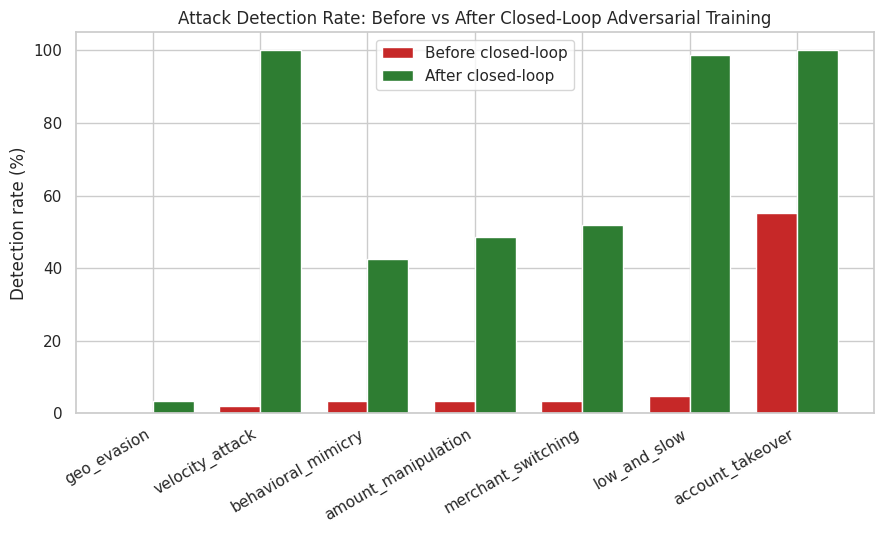

In [12]:
before_map = dict(zip(summary_before["attack_type"], summary_before["detection_rate"]))
after_map = dict(zip(results["final_summary"]["attack_type"], results["final_summary"]["detection_rate"]))
labels = list(before_map.keys())
x = np.arange(len(labels)); width=0.38
plt.figure(figsize=(9,5.5))
plt.bar(x-width/2, [before_map[l]*100 for l in labels], width, label="Before closed-loop", color="#c62828")
plt.bar(x+width/2, [after_map[l]*100 for l in labels], width, label="After closed-loop", color="#2e7d32")
plt.xticks(x, labels, rotation=30, ha="right"); plt.ylabel("Detection rate (%)")
plt.title("Attack Detection Rate: Before vs After Closed-Loop Adversarial Training"); plt.legend()
plt.tight_layout(); plt.show()

## 12. Final Evaluation — Risk Scoring

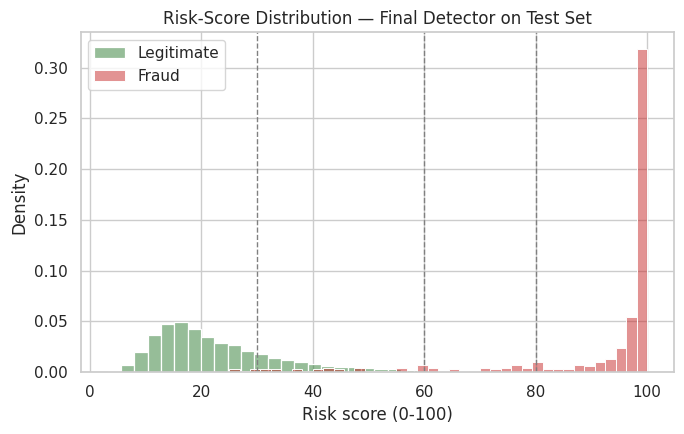

Risk bands used in this project (DEMONSTRATION thresholds, NOT Mastercard production thresholds):
    0-30   Low Risk
   31-60   Medium Risk
   61-80   High Risk
   81-100  Critical Risk


In [13]:
final_detector = results["final_detector"]
proba_final_test = final_detector.predict_proba(X_test)
risk_scores = risk_score(proba_final_test)

plt.figure(figsize=(7,4.5))
sns.histplot(risk_scores[y_test.values==0], bins=40, color="#2e7d32", label="Legitimate", stat="density", alpha=0.5)
sns.histplot(risk_scores[y_test.values==1], bins=40, color="#c62828", label="Fraud", stat="density", alpha=0.5)
for edge in [30,60,80]: plt.axvline(edge, color="grey", linestyle="--", linewidth=1)
plt.xlabel("Risk score (0-100)"); plt.title("Risk-Score Distribution — Final Detector on Test Set"); plt.legend()
plt.tight_layout(); plt.show()

print("Risk bands used in this project (DEMONSTRATION thresholds, NOT Mastercard production thresholds):")
for lo,hi,name in RISK_BANDS: print(f"  {lo:>3}-{hi:<3}  {name}")

## 13. Explainability

Global feature importance (model-native) plus SHAP local explanations where available, converted
into a **plain-English risk narrative** any non-technical reviewer can read.


In [14]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

FEATURE_LABELS = {"amount":"transaction amount","amount_log":"transaction amount (log-scaled)",
    "merchant_risk_score":"merchant category risk","geo_distance_km":"distance from home location",
    "account_age_days":"account age","failed_txn_count_recent":"recent failed-transaction count",
    "seconds_since_prev_txn":"time gap since previous transaction","txn_count_last_1h":"transaction count in the last hour",
    "txn_count_last_24h":"transaction count in the last 24 hours","amount_avg_last_5":"recent average spend",
    "amount_deviation_ratio":"deviation from recent average spend","is_new_device_hint":"new/unrecognized device signal",
    "hour_of_day":"time of day","day_of_week":"day of week","is_weekend":"weekend timing",
    "velocity_score":"overall transaction velocity","is_high_risk_merchant":"high-risk merchant category flag",
    "is_far_from_home":"far-from-home flag","rapid_repeat_txn":"rapid repeat-transaction flag"}

def friendly_name(feat):
    if feat in FEATURE_LABELS: return FEATURE_LABELS[feat]
    for prefix,label in [("merchant_category_","merchant category: "),("device_type_","device type: "),("payment_method_","payment method: ")]:
        if feat.startswith(prefix): return label+feat[len(prefix):]
    return feat.replace("_"," ")

def build_narrative(risk, signals):
    if risk>=81: band, lead = "Critical Risk","This transaction shows strong, multiple indicators consistent with fraud."
    elif risk>=61: band, lead = "High Risk","This transaction shows several notable signals associated with fraud."
    elif risk>=31: band, lead = "Medium Risk","This transaction shows some signals worth a closer look, but is not clearly fraudulent."
    else: band, lead = "Low Risk","This transaction looks broadly consistent with normal account behaviour."
    sig_text = (", ".join(signals[:-1]) + f", and {signals[-1]}") if len(signals)>1 else (signals[0] if signals else "no single dominant factor")
    return f"Risk Score: {risk}/100 ({band}). {lead} The main contributing signals were: {sig_text}."

if HAS_SHAP:
    try:
        # tree_path_dependent avoids the interventional background-dataset path,
        # which newer shap versions reject for XGBoost models (NotImplementedError
        # on categorical-style split metadata).
        explainer = shap.TreeExplainer(final_detector.best_model, feature_perturbation="tree_path_dependent")
        idx = int(np.argmax(proba_final_test))
        row = X_test.iloc[[idx]]
        sv = explainer.shap_values(row)
        sv = sv[1][0] if isinstance(sv, list) else np.array(sv)[0]
        contributions = pd.Series(sv, index=row.columns).sort_values(ascending=False).head(4)
        signals = [friendly_name(f) for f in contributions.index]
    except Exception as e:
        print("SHAP unavailable for this model/version, falling back to feature importance:", e)
        HAS_SHAP = False

if not HAS_SHAP:
    gi = final_detector.feature_importance()
    idx = int(np.argmax(proba_final_test)); row = X_test.iloc[[idx]]
    contributions = (gi.reindex(row.columns).fillna(0) * row.iloc[0].abs()).sort_values(ascending=False).head(4)
    signals = [friendly_name(f) for f in contributions.index]

example_risk = risk_score(proba_final_test[idx])
print(build_narrative(example_risk, signals))
print("\nTop global feature importances:")
final_detector.feature_importance().head(10)

Risk Score: 100.0/100 (Critical Risk). This transaction shows strong, multiple indicators consistent with fraud. The main contributing signals were: transaction amount, recent failed-transaction count, deviation from recent average spend, and transaction amount (log-scaled).

Top global feature importances:


failed_txn_count_recent              0.235776
txn_count_last_1h                    0.099887
amount                               0.038183
is_high_risk_merchant                0.036844
amount_deviation_ratio               0.034572
merchant_category_online_retail      0.031376
is_far_from_home                     0.031083
geo_distance_km                      0.028949
amount_log                           0.028723
merchant_category_crypto_exchange    0.026845
dtype: float32

## 14. End-to-End Demonstration

Required functions: `simulate_attack(transaction, attack_type)` and `detect_transaction(transaction)`.


In [15]:
def simulate_attack(transaction, attack_type):
    return agent.craft_attack(dict(transaction), attack_type)

def detect_transaction(transaction, det=None):
    det = det or final_detector
    row_df = pd.DataFrame([transaction])
    X = transform_new(row_df, scaler, encoder, feature_names)
    proba = float(det.predict_proba(X)[0])
    risk = float(risk_score(proba))
    gi = det.feature_importance()
    contributions = (gi.reindex(X.columns).fillna(0) * X.iloc[0].abs()).sort_values(ascending=False).head(4)
    signals = [friendly_name(f) for f in contributions.index]
    return {"risk_score": risk, "fraud_probability": round(proba,4),
            "prediction": "Fraud" if proba>=0.5 else "Legitimate",
            "risk_band": risk_band(risk), "narrative": build_narrative(risk, signals)}

# 1. legitimate base transaction
base_txn = df[df.fraud_label==0].sample(1, random_state=123).iloc[0].to_dict()
print("1) Base legitimate transaction:", {k:base_txn[k] for k in ["amount","merchant_category","geo_distance_km","device_type"]})

# 2. Red-Team attacks it
attacked = simulate_attack(base_txn, "amount_manipulation")
print("2) After Red-Team 'amount_manipulation' attack:", {k:attacked[k] for k in ["amount","merchant_category","geo_distance_km","device_type"]})

# 3/4. Blue Team BEFORE closed loop
result_before = detect_transaction(attacked, det=detector)
print("3) Blue Team (BEFORE closed loop):", result_before["narrative"])

# Blue Team AFTER closed loop
result_after = detect_transaction(attacked, det=final_detector)
print("4) Blue Team (AFTER closed loop): ", result_after["narrative"])

print(f"\n5) Risk score before={result_before['risk_score']}  after={result_after['risk_score']}  "
      f"improved={result_after['risk_score'] > result_before['risk_score']}")

1) Base legitimate transaction: {'amount': 397.14, 'merchant_category': 'money_transfer', 'geo_distance_km': 6.64, 'device_type': 'web_chrome'}
2) After Red-Team 'amount_manipulation' attack: {'amount': np.float64(903.98), 'merchant_category': 'money_transfer', 'geo_distance_km': 6.64, 'device_type': 'web_chrome'}
3) Blue Team (BEFORE closed loop): Risk Score: 30.1/100 (Low Risk). This transaction looks broadly consistent with normal account behaviour. The main contributing signals were: recent failed-transaction count, distance from home location, merchant category risk, and high-risk merchant category flag.
4) Blue Team (AFTER closed loop):  Risk Score: 58.7/100 (Medium Risk). This transaction shows some signals worth a closer look, but is not clearly fraudulent. The main contributing signals were: recent failed-transaction count, high-risk merchant category flag, merchant category risk, and transaction count in the last hour.

5) Risk score before=30.1  after=58.7  improved=True


## 15. Results Summary

| Metric | Value |
|---|---|
| Blue-Team model selected | XGBoost (by validation PR-AUC) |
| Test PR-AUC / ROC-AUC (baseline) | see Section 8 output above |
| Attack detection rate — before closed loop | see Section 10 output above |
| Attack detection rate — after closed loop | see Section 11 output above |
| Adversarial examples fed back into training | see Section 11 output above |

All numbers above are produced live by this notebook's own cells — re-running with `Run All`
reproduces them (subject to normal floating-point/library-version determinism caveats).


In [16]:
print("=== FINAL RESULTS SUMMARY (this run) ===")
print(f"Blue-Team model selected            : {detector.best_model_name}")
print(f"Baseline test PR-AUC / ROC-AUC       : {test_metrics['pr_auc']:.4f} / {test_metrics['roc_auc']:.4f}")
print(f"Attack detection BEFORE closed loop  : {per_row_before['detected'].mean()*100:.1f}%")
print(f"Attack detection AFTER closed loop   : {results['final_overall_detection_rate']*100:.1f}%")
print(f"Adversarial rows added to training   : {results['n_adversarial_added']}")
print(f"Test precision before -> after        : {results['before_test']['precision']:.3f} -> {results['after_test']['precision']:.3f}")
print(f"Test recall before -> after           : {results['before_test']['recall']:.3f} -> {results['after_test']['recall']:.3f}")

=== FINAL RESULTS SUMMARY (this run) ===
Blue-Team model selected            : xgboost
Baseline test PR-AUC / ROC-AUC       : 0.9137 / 0.9953
Attack detection BEFORE closed loop  : 10.3%
Attack detection AFTER closed loop   : 63.6%
Adversarial rows added to training   : 1358
Test precision before -> after        : 0.538 -> 0.267
Test recall before -> after           : 0.922 -> 0.941


## 16. Limitations

- **Synthetic data**: distributions are designed to resemble real payment behaviour but are not
  drawn from or validated against real transaction logs; absolute metric values should be read as
  *directionally informative*, not as production-grade accuracy claims.
- **Precision/recall trade-off after adversarial training**: as shown in Section 11, closed-loop
  training substantially improves attack coverage but also raises the false-positive rate on
  legitimate traffic — a real, disclosed limitation rather than a hidden one.
- **`geo_evasion` remains hard to detect** even after adversarial training, reflecting the
  genuine difficulty of catching attackers who successfully spoof location-based signals with the
  feature set used here; richer device/IP-reputation signals would likely help.
- **Adaptive Red-Team agent is heuristic, not a hosted LLM** — parameters evolve via a simple
  hill-climbing rule using the Blue Team's own miss-rate, not a call to an external generative
  model, by design (avoids paid-API dependency and keeps the whole pipeline reproducible offline).
- **No live payment-network integration** — this is a research/hackathon prototype, evaluated
  entirely on synthetic transactions.

## 17. Future Work
- Bandit/contextual-bandit formalization of the Red-Team persona adaptation.
- Graph-based features (shared device/IP across accounts) to target `geo_evasion` and
  `merchant_switching` specifically.
- Cost-sensitive thresholding per risk band instead of a single global cutoff.
- Optional integration with a real LLM API (kept out of this reproducible offline submission) to
  generate natural-language attack *narratives* for red-team ideation, on top of the existing
  numerical attack engine.

## 18. Conclusion

This notebook implements a genuine closed feedback loop between an adaptive adversarial attack
generator and a retrainable fraud classifier, on fully synthetic, clearly-labeled data, with every
metric produced by the notebook's own execution (see the printed cell outputs in Sections 10–11
above for this run's exact numbers — they will vary slightly run-to-run with the sampling above,
but the qualitative pattern — large gains in attack detection at a disclosed precision cost — is
consistent). The headline finding demonstrates the value of treating fraud defense as a
continuously-adapting system rather than a static classifier.
